# Validating DSM for Lie Derivatives

This notebook checks that the following loss function indeed learns the correct score


$$ L = \mathbb{E}_{p_\sigma(\tilde{R}, R)} \left[ \frac{1}{2} \parallel s_\theta(R, \sigma) - \mathcal{L}_\mathcal{V}(\log p_\sigma(\tilde{R}| R))  \parallel_2^2   \right]$$

In [1]:
%pylab inline
import jax.numpy as jnp
import jax
from jaxlie import SO3
from so3dm.distributions.isotropic_gaussian import IsotropicGaussianSO3

center = SO3.identity()
def make_dist(sigma=0.):
  """
  Returns a mixture of Gaussians, convolved with a Gaussian of specified sigma
  """
  return IsotropicGaussianSO3(center, jnp.sqrt(0.2**2+sigma**2))

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [2]:
import haiku as hk
import optax

# Create a random sequence
rng_seq = hk.PRNGSequence(42)

In [3]:
# Create our reference distribution, and noisy distribution
sigma_n = 0.5
ref_dist = make_dist()
dist = make_dist(sigma_n)

In [4]:
def true_score(q):
  return jax.grad(lambda s: dist.log_prob((SO3(q) @ SO3.exp(s)).wxyz))(jnp.zeros(3))

In [5]:
def score_noise(q0,key):
    dist_noise = IsotropicGaussianSO3(q0, sigma_n)
    qn = dist_noise.sample(seed=key)
    def score_fn(q):
      return jax.grad(lambda s: dist_noise.log_prob((SO3(q) @ SO3.exp(s)).wxyz))(jnp.zeros(3))
    return qn, score_fn(qn)

In [6]:
@jax.jit
@jax.vmap
def get_batch(key):
    k1,k2 = jax.random.split(key)
    q0 = ref_dist.sample(seed=k1)
    qn, sn = score_noise(q0, k2)
    st = true_score(qn)
    return {'q0':q0, 'qn':qn, 'sn':sn, 'st':st}

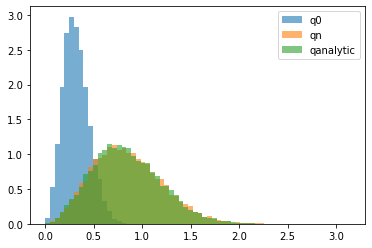

In [7]:
# Checking that distributions add as we expect
batch = get_batch(jax.random.split(next(rng_seq),10000))

angles = jnp.linalg.norm(jax.vmap(lambda x: SO3(x).log())(batch['q0']),axis=-1)
hist(angles,64, density=True, range=[0,pi], label='q0',alpha=0.6);

# Let's look at the distribution of axis angles
angles = jnp.linalg.norm(jax.vmap(lambda x: SO3(x).log())(batch['qn']),axis=-1)
hist(angles,64, density=True, range=[0,pi], label='qn',alpha=0.6);


qtest = dist.sample(10000, seed=next(rng_seq))
angles = jnp.linalg.norm(jax.vmap(lambda x: SO3(x).log())(qtest),axis=-1)
hist(angles,64, density=True, range=[0,pi], label='qanalytic',alpha=0.6);

legend()

In [8]:
def forward(x):
    net = hk.nets.MLP([512, 256, 128], activation=jax.nn.leaky_relu)(x)
    net = hk.Linear(3)(net)
    return net

model = hk.without_apply_rng(hk.transform(forward))
params = model.init(jax.random.PRNGKey(0), jnp.zeros([1,4]))

losses = []
totsteps=0
from flax.metrics import tensorboard
summary_writer = tensorboard.SummaryWriter('test')

In [9]:
optimizer = optax.adam(learning_rate=1e-4)

In [10]:
opt_state = optimizer.init(params)

In [11]:
def loss_fn(params, rng_key, batch):
    score_pred = model.apply(params, batch['qn'])
    
    loss = (jnp.linalg.norm(score_pred - batch['sn'], axis=-1))**2
    
    return jnp.mean(loss)

In [12]:
@jax.jit
def update(params, rng_key, opt_state, batch):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng_key, batch)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss, new_params, new_opt_state

In [26]:
for step in range(20000):
    batch = get_batch(jax.random.split(next(rng_seq),1024))
    if isnan(batch['sn'].mean()):
        continue
    loss, params, opt_state = update(params, next(rng_seq), opt_state, batch)
    totsteps+=1
    losses.append(loss)
    if isnan(loss):
        break
    if step % 5 ==0:
        summary_writer.scalar('train_loss', loss, totsteps)

In [27]:
batch = get_batch(jax.random.split(next(rng_seq),1024))

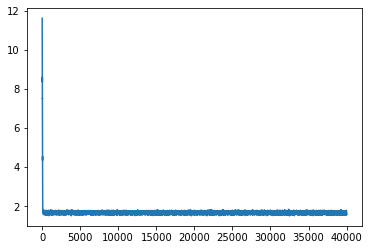

In [28]:
plot(losses)

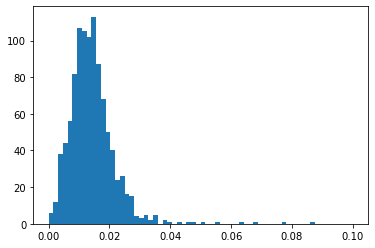

In [29]:
# For sigma = 0.1
hist(jnp.linalg.norm(model.apply(params, batch['qn']) - batch['st'], axis=1)/jnp.linalg.norm(batch['st'], axis=1),64,range=[0,0.1]);


(-1.0, 1.0)

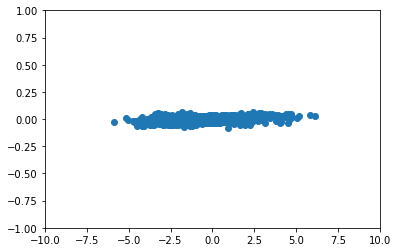

In [32]:
scatter(batch['st'][:,1], model.apply(params, batch['qn'])[:,0] -  batch['st'][:,0])
xlim(-10,10)
ylim(-1,1)

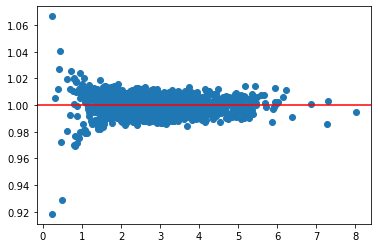

In [31]:
scatter(jnp.linalg.norm(batch['st'],axis=-1), jnp.linalg.norm(model.apply(params, batch['qn']),axis=-1) / 
                          jnp.linalg.norm(batch['st'],axis=-1))

axhline(jnp.median(jnp.linalg.norm(model.apply(params, batch['qn']),axis=-1) / 
                          jnp.linalg.norm(batch['st'],axis=-1)),color='red')

In [19]:
# That was for sigma of 0.25
jnp.median(jnp.linalg.norm(model.apply(params, batch['qn']),axis=-1) / 
                          jnp.linalg.norm(batch['st'],axis=-1))

DeviceArray(1.0014867, dtype=float32)